# EDA: MovieLens 1M

A narrative walkthrough of the dataset before any modeling. This mirrors the checks
that motivate the framing choices in `README.md`: why implicit feedback, why a
temporal split, and why coverage matters alongside accuracy.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.config import RAW_DIR, POSITIVE_THRESHOLD

ratings = pd.read_csv(RAW_DIR / 'ratings.csv')
movies = pd.read_csv(RAW_DIR / 'movies.csv')
print(f'{len(ratings):,} ratings, {ratings.user_id.nunique():,} users, {ratings.movie_id.nunique():,} movies')

1,000,209 ratings, 6,040 users, 3,706 movies


## Rating distribution

Ratings are 1 to 5 stars. This project treats a rating of 4 or 5 as a positive
implicit interaction, everything else (including a rating of 1-3, and every
movie a user never rated at all) as unobserved rather than negative. A user who
skipped a movie might have loved it; there's no signal either way.

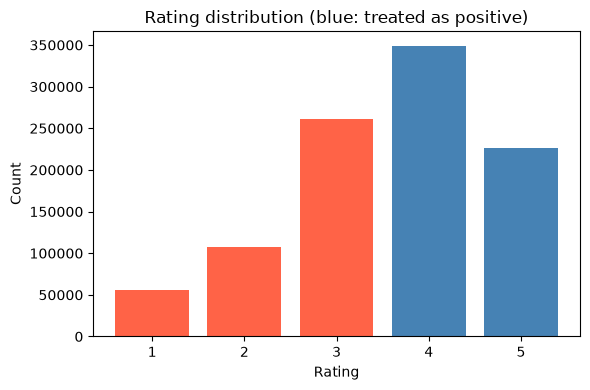

57.5% of all ratings count as a positive interaction


In [2]:
counts = ratings['rating'].value_counts().sort_index()
colors = ['tomato' if r < POSITIVE_THRESHOLD else 'steelblue' for r in counts.index]
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values, color=colors)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating distribution (blue: treated as positive)')
plt.tight_layout()
plt.show()

positive_share = (ratings['rating'] >= POSITIVE_THRESHOLD).mean()
print(f'{positive_share:.1%} of all ratings count as a positive interaction')

## The long tail

Most movies get very few positive interactions; a small set of blockbusters
dominate. This is exactly why a popularity baseline is dangerously competitive
(it's cheap and it's right a lot of the time for head items) and why coverage
is reported alongside accuracy for every model in this project, a model that
just re-serves the same popular titles to everyone can look accurate while
being useless as a discovery tool.

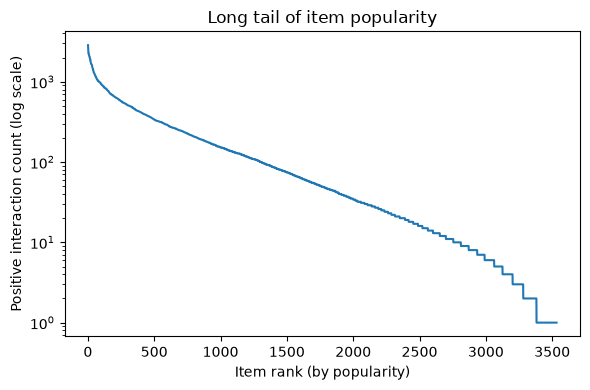

The top 10% of movies (353 of them) account for 52.3% of all positive interactions


In [3]:
positives = ratings[ratings['rating'] >= POSITIVE_THRESHOLD]
item_counts = positives.groupby('movie_id').size().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(item_counts) + 1), item_counts.values)
plt.yscale('log')
plt.xlabel('Item rank (by popularity)')
plt.ylabel('Positive interaction count (log scale)')
plt.title('Long tail of item popularity')
plt.tight_layout()
plt.show()

top_10pct = int(len(item_counts) * 0.1)
share = item_counts.iloc[:top_10pct].sum() / item_counts.sum()
print(f'The top 10% of movies ({top_10pct:,} of them) account for {share:.1%} of all positive interactions')

## User activity and why the split is temporal, not random

Users vary hugely in how many movies they've rated. Only users with at least 15
positive interactions get held-out validation/test slices (see `src/split.py`);
below that there isn't enough history to evaluate a top-10 ranking meaningfully,
so those users stay train-only.

The split itself is per-user and temporal: each qualifying user's chronologically
last 5 positives are test, the 5 before that are validation, and everything
earlier is train. A random split would let a user's *future* interactions leak
into training while asking the model to predict their *past*, which inflates
offline metrics in a way that never survives deployment.

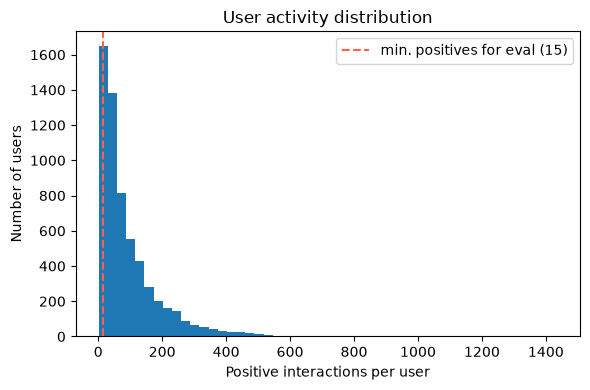

93.7% of users have enough history to get a held-out test slice


In [4]:
user_activity = positives.groupby('user_id').size()
plt.figure(figsize=(6, 4))
plt.hist(user_activity, bins=50)
plt.axvline(15, color='tomato', linestyle='--', label='min. positives for eval (15)')
plt.xlabel('Positive interactions per user')
plt.ylabel('Number of users')
plt.title('User activity distribution')
plt.legend()
plt.tight_layout()
plt.show()

eligible = (user_activity >= 15).mean()
print(f'{eligible:.1%} of users have enough history to get a held-out test slice')

## Genres

A quick look at genre frequency, used later by the content side of a hybrid
recommender if one gets added; for now this project sticks to collaborative
signals only (popularity, item-item CF, and ALS).

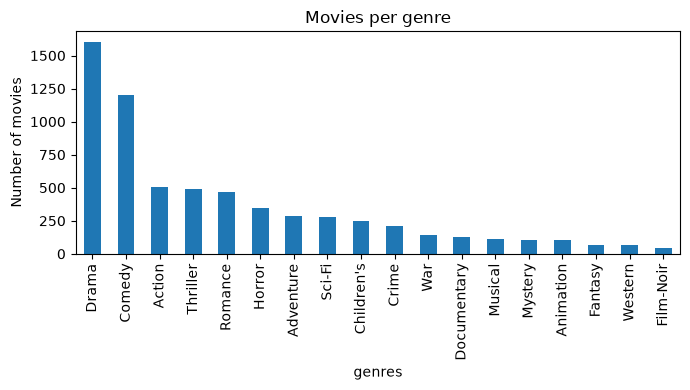

In [5]:
genre_counts = movies['genres'].str.split('|').explode().value_counts()
plt.figure(figsize=(7, 4))
genre_counts.plot(kind='bar')
plt.ylabel('Number of movies')
plt.title('Movies per genre')
plt.tight_layout()
plt.show()